1. Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/q2_customers.csv')

df = pd.read_csv('../data/q2_customers.csv')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


MARKDOWN -

Scaling is required because K-Means uses Euclidean distance

2. Choosing K — Elbow Method

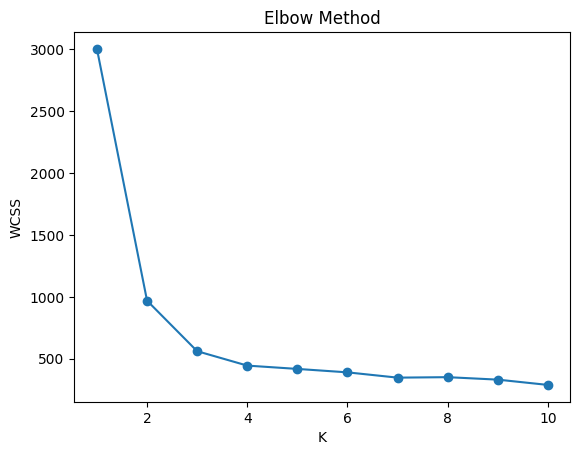

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

Markdown:

Optimal K = elbow point (e.g., 3 or 4)


3. K-Means Clustering

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
print(centroids)

        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.132214      1.235574         -1.106680     1.253260   
2 -0.004449     -0.168055         -0.041370    -0.290670   

   days_since_last_visit  num_categories_purchased  
0              -0.813494                 -1.045346  
1               1.125725                  1.172991  
2              -0.287579                 -0.095968  


Markdown:

*   Cluster 0: High spend, frequent visits → loyal customers
*   Cluster 1: Low spend → occasional buyers
*   Cluster 2: High basket size but low visits → bulk shoppers





4. Dimensionality Reduction with PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(pd.DataFrame(pca.components_, columns=df.columns[:-1]))

[0.83560354 0.05568764]
        age  annual_spend  visits_per_month  basket_size  \
0  0.411569       0.42154         -0.410399     0.412012   
1 -0.259432      -0.03327          0.208318    -0.195402   

   days_since_last_visit  num_categories_purchased  
0               0.378582                  0.414017  
1               0.911194                 -0.140479  


MARKDOWN -

*  PC1 captures spending behavior
*  PC2 captures visit frequency


5. Cluster Visualisation

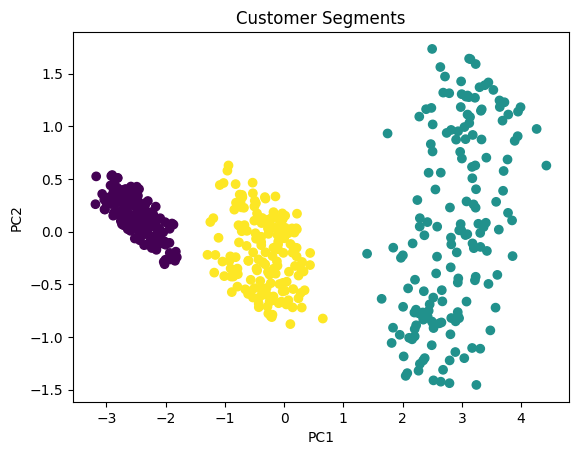

In [8]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.show()